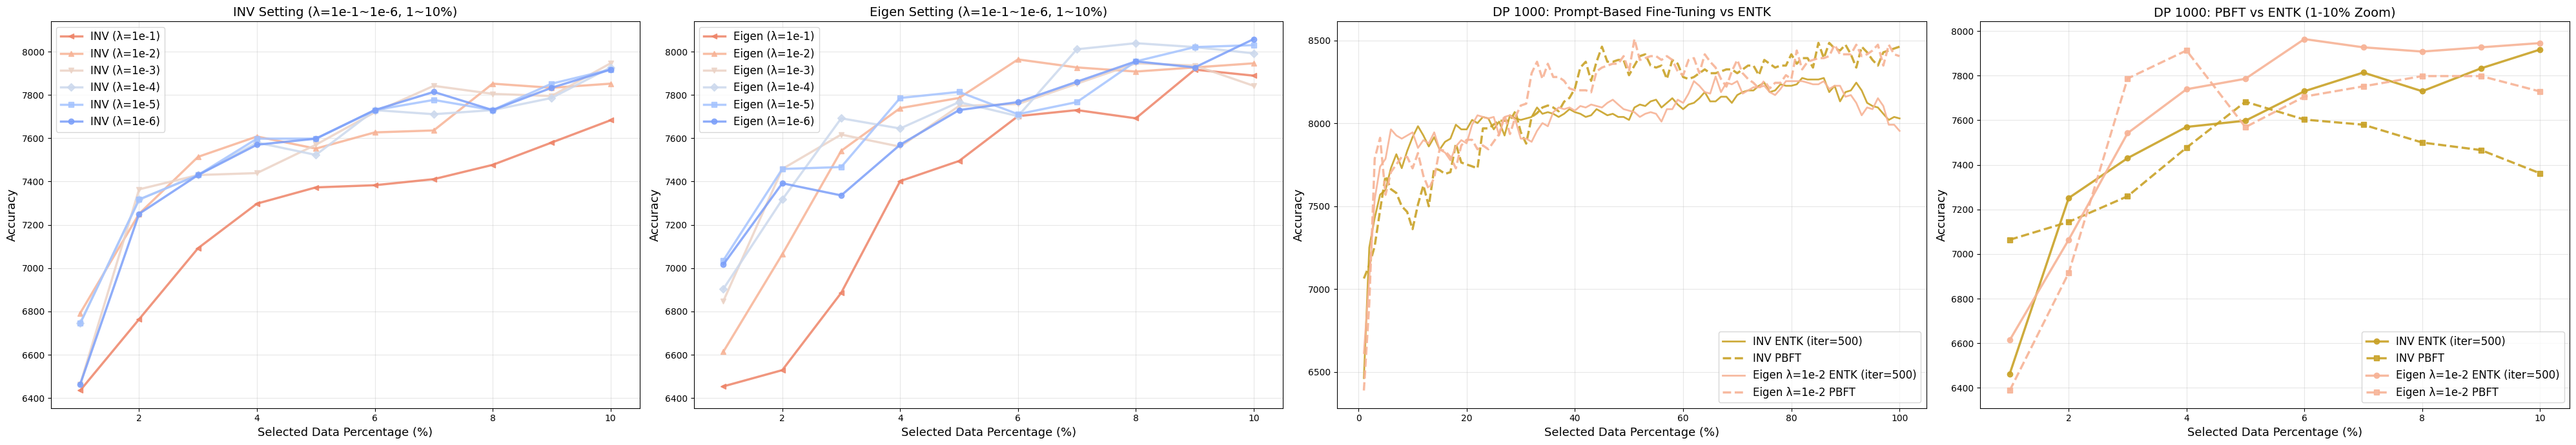

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [6463, 7251, 7430, 7570, 7598, 7730, 7814, 7730, 7833, 7917, 7983, 7927, 7861, 7917, 7842, 7889, 7908, 7992, 7964, 7964, 8021, 8002, 8039, 8030, 7964, 8011, 7927, 8049, 8030, 8021, 8030, 8039, 8096, 8058, 8068, 8058, 8039, 8058, 8086, 8068, 8058, 8039, 8049, 8086, 8068, 8049, 8058, 8039, 8039, 8021, 8096, 8114, 8105, 8133, 8143, 8096, 8124, 8152, 8114, 8086, 8114, 8124, 8152, 8189, 8133, 8133, 8161, 8161, 8124, 8171, 8189, 8199, 8199, 8227, 8246, 8189, 8199, 8236, 8227, 8227, 8236, 8274, 8265, 8265, 8265, 8274, 8189, 8227, 8133, 8189, 8199, 8246, 8199, 8124, 8105, 8096, 8058, 8021, 8039, 8030]
inv_lam1e_5      = [6745, 7317, 7430, 7598, 7598, 7730, 7777, 7730, 7852, 7917, 7992, 7983, 7889, 7917, 7842, 7889, 7908, 7964, 7974, 7992, 8021, 8002, 7992, 7955, 7964, 7974, 7927, 8021, 8039, 8002, 8058, 8030, 8039, 8086, 8068, 8049, 8077, 8058, 8058, 8058, 8049, 8039, 8049, 8058, 8068, 8058, 8077, 8077, 8039, 8011, 8096, 8114, 8105, 8171, 8133, 8077, 8143, 8124, 8114, 8096, 8105, 8133, 8152, 8189, 8133, 8105, 8124, 8143, 8124, 8171, 8171, 8199, 8189, 8208, 8208, 8227, 8199, 8236, 8227, 8265, 8218, 8246, 8255, 8265, 8265, 8274, 8236, 8227, 8133, 8189, 8199, 8246, 8199, 8124, 8161, 8096, 8058, 8021, 8039, 8030]
inv_lam1e_4      = [6745, 7317, 7430, 7580, 7523, 7730, 7711, 7730, 7786, 7927, 7927, 7936, 7852, 7899, 7833, 7917, 7974, 7992, 7946, 7974, 7974, 7946, 7936, 7992, 7974, 8021, 8077, 8002, 8021, 8030, 8068, 8068, 8086, 8096, 8068, 8077, 8077, 8068, 8058, 8077, 8049, 8039, 8021, 8058, 8077, 8039, 8049, 8049, 8021, 8011, 8039, 8049, 8096, 8124, 8133, 8114, 8114, 8105, 8124, 8105, 8114, 8133, 8143, 8180, 8124, 8133, 8180, 8124, 8114, 8143, 8180, 8199, 8199, 8218, 8189, 8208, 8227, 8236, 8218, 8283, 8274, 8274, 8302, 8227, 8265, 8265, 8189, 8208, 8189, 8189, 8246, 8246, 8171, 8124, 8096, 8096, 8058, 8021, 8039, 8030]
inv_lam1e_3      = [6463, 7364, 7430, 7439, 7570, 7720, 7842, 7805, 7795, 7946, 7899, 7889, 7861, 7861, 7852, 7899, 7964, 7936, 7946, 7983, 7974, 7946, 7964, 7917, 7983, 7946, 7974, 8039, 8011, 7983, 8002, 8058, 8077, 8086, 8096, 8058, 8068, 8105, 8077, 8058, 8021, 8021, 8049, 8058, 8039, 8039, 8068, 8124, 8096, 8068, 8096, 8114, 8096, 8096, 8124, 8105, 8077, 8105, 8114, 8068, 8161, 8143, 8143, 8180, 8161, 8161, 8189, 8152, 8189, 8152, 8189, 8236, 8255, 8236, 8246, 8246, 8246, 8293, 8255, 8265, 8255, 8283, 8274, 8236, 8218, 8218, 8218, 8199, 8171, 8199, 8152, 8246, 8180, 8133, 8049, 8058, 8058, 8021, 8039, 8049]
inv_lam1e_2      = [6792, 7251, 7514, 7608, 7552, 7627, 7636, 7852, 7833, 7852, 7917, 7927, 7899, 7814, 7814, 7824, 7842, 7871, 7908, 7899, 7917, 7983, 7955, 7974, 7946, 7974, 7992, 8039, 8021, 8011, 8049, 8039, 8058, 8030, 8058, 8039, 8077, 8049, 8086, 8096, 8105, 8171, 8143, 8161, 8096, 8068, 8058, 8077, 8086, 8096, 8077, 8077, 8077, 8105, 8105, 8077, 8086, 8058, 8049, 8124, 8086, 8096, 8105, 8114, 8096, 8096, 8143, 8105, 8124, 8143, 8171, 8171, 8274, 8255, 8311, 8274, 8330, 8274, 8265, 8255, 8255, 8293, 8255, 8265, 8283, 8208, 8208, 8218, 8199, 8293, 8274, 8274, 8152, 8124, 8161, 8096, 8058, 8096, 8021, 8068]
inv_lam1e_1      = [6435, 6764, 7092, 7298, 7373, 7383, 7411, 7477, 7580, 7683, 7683, 7702, 7739, 7692, 7730, 7702, 7786, 7730, 7824, 7833, 7889, 7871, 7917, 8002, 8021, 8049, 8021, 8039, 8021, 7992, 8021, 8002, 8011, 8030, 8039, 7955, 7992, 8002, 7946, 8068, 8058, 8058, 8058, 8049, 8133, 8049, 8077, 8068, 8039, 8021, 8002, 8021, 8030, 7992, 8068, 8049, 8086, 8077, 8105, 8180, 8114, 8058, 8058, 8058, 8105, 8133, 8133, 8189, 8133, 8171, 8133, 8152, 8199, 8218, 8199, 8236, 8189, 8236, 8208, 8236, 8265, 8246, 8293, 8265, 8293, 8302, 8274, 8265, 8274, 8255, 8218, 8283, 8218, 8246, 8246, 8180, 8180, 8199, 8124, 8133]
eigen_lam1e_6    = [7017, 7392, 7336, 7570, 7730, 7767, 7861, 7955, 7927, 8058, 7936, 7955, 7880, 7899, 7936, 7964, 7955, 7992, 7852, 7899, 7739, 7720, 7589, 7627, 7420, 7195, 7336, 6914, 6398, 6116, 7064, 7233, 7158, 7167, 7289, 7392, 7448, 7758, 7730, 7786, 7842, 7946, 7917, 7908, 7946, 7964, 8030, 8096, 8133, 8161, 8133, 8189, 8143, 8124, 8124, 8058, 8152, 8152, 8124, 8208, 8236, 8227, 8208, 8255, 8208, 8152, 8199, 8218, 8152, 8171, 8171, 8143, 8114, 8171, 8189, 8171, 8199, 8199, 8227, 8199, 8199, 8171, 8208, 8152, 8152, 8143, 8152, 8105, 8077, 8143, 8114, 8096, 8058, 8086, 8077, 8096, 8049, 7992, 7955, 7964]
eigen_lam1e_5    = [7036, 7458, 7467, 7786, 7814, 7711, 7767, 7955, 8021, 8030, 7964, 7899, 7946, 7871, 7908, 8021, 7852, 7749, 7702, 7608, 7692, 7655, 7645, 7608, 7326, 7176, 7036, 6848, 6754, 6801, 6904, 7054, 7026, 7129, 7430, 7467, 7373, 7514, 7589, 7664, 7655, 7674, 7842, 7927, 7880, 7936, 7964, 8152, 8086, 8096, 8096, 8114, 8096, 8049, 8086, 8133, 8096, 8124, 8096, 8199, 8208, 8208, 8218, 8302, 8180, 8161, 8114, 8246, 8236, 8199, 8208, 8283, 8265, 8283, 8218, 8218, 8227, 8208, 8171, 8265, 8199, 8180, 8180, 8255, 8171, 8161, 8152, 8096, 8077, 8077, 8049, 8049, 8049, 8124, 8086, 8049, 8068, 7964, 7974, 7964]
eigen_lam1e_4    = [6904, 7317, 7692, 7645, 7767, 7702, 8011, 8039, 8021, 7992, 7992, 8002, 7946, 8030, 7889, 7852, 7739, 7711, 7608, 7636, 7598, 7580, 7542, 7458, 7355, 7355, 7195, 7120, 7036, 6839, 6970, 6951, 6942, 7167, 7298, 7523, 7627, 7702, 7749, 7749, 7880, 7936, 7946, 7871, 7983, 8039, 8105, 8077, 8039, 8143, 8096, 8133, 8114, 8133, 8199, 8133, 8096, 8133, 8180, 8152, 8152, 8246, 8246, 8218, 8189, 8218, 8171, 8180, 8180, 8199, 8227, 8255, 8227, 8208, 8208, 8218, 8227, 8180, 8227, 8227, 8302, 8283, 8265, 8274, 8274, 8171, 8114, 8096, 8049, 8096, 8096, 8049, 8086, 8114, 8086, 8077, 8058, 7955, 7917, 7964]
eigen_lam1e_3    = [6848, 7458, 7617, 7561, 7749, 7758, 7852, 7946, 7936, 7842, 7842, 7899, 7927, 7824, 7842, 7842, 7795, 7833, 7758, 7814, 7767, 7702, 7720, 7655, 7627, 7777, 7720, 7664, 7636, 7664, 7636, 7720, 7730, 7749, 7655, 7758, 7739, 7899, 7899, 7946, 7927, 7964, 8011, 8021, 8058, 8143, 8124, 8058, 8086, 8143, 8105, 8068, 8114, 8039, 8039, 8030, 8049, 8180, 8143, 8143, 8133, 8161, 8180, 8171, 8180, 8180, 8227, 8208, 8218, 8143, 8180, 8199, 8208, 8180, 8236, 8255, 8265, 8189, 8255, 8255, 8208, 8246, 8246, 8218, 8255, 8143, 8143, 8114, 8077, 8086, 8152, 8114, 8086, 8096, 8021, 8049, 8086, 8021, 7964, 7964]
eigen_lam1e_2    = [6614, 7064, 7542, 7739, 7786, 7964, 7927, 7908, 7927, 7946, 7852, 7899, 7880, 7946, 7842, 7824, 7777, 7861, 7899, 7880, 7992, 8049, 8039, 8030, 8039, 7927, 8039, 8049, 8021, 7908, 7908, 7889, 7955, 8002, 7983, 8068, 8096, 8086, 8096, 8077, 8105, 8096, 8114, 8105, 8096, 8124, 8143, 8114, 8086, 8077, 8068, 8039, 8058, 8068, 8058, 8011, 8086, 8086, 8143, 8124, 8180, 8255, 8227, 8189, 8180, 8283, 8189, 8246, 8236, 8255, 8180, 8199, 8218, 8218, 8227, 8189, 8171, 8208, 8255, 8255, 8255, 8255, 8246, 8236, 8236, 8255, 8208, 8227, 8227, 8161, 8171, 8124, 8049, 8096, 8086, 8152, 8105, 7992, 7992, 7955]
eigen_lam1e_1    = [6454, 6529, 6886, 7402, 7495, 7702, 7730, 7692, 7917, 7889, 7880, 7936, 7946, 7899, 7964, 7889, 8039, 7992, 7917, 7983, 7974, 8030, 8030, 8021, 8011, 8021, 8030, 8011, 8039, 8021, 8068, 8077, 8068, 8068, 8058, 8030, 8049, 8058, 8068, 8030, 8049, 8058, 8039, 8077, 8086, 8096, 8086, 8068, 8077, 8068, 8105, 8105, 8114, 8096, 8096, 8114, 8086, 8143, 8124, 8143, 8133, 8124, 8143, 8133, 8152, 8152, 8161, 8133, 8133, 8124, 8180, 8152, 8199, 8218, 8189, 8218, 8218, 8208, 8274, 8218, 8189, 8189, 8199, 8180, 8218, 8199, 8161, 8161, 8143, 8171, 8218, 8189, 8171, 8133, 8152, 8077, 8096, 8058, 8002, 8002]

# Prediction with random shapley values
r_inv_lam1e_6     = [5619, 6670, 7083, 7195, 7214, 7205, 7270, 7326, 7280, 7373, 7402, 7373, 7364, 7486, 7570, 7589, 7711, 7730, 7533, 7580, 7542, 7561, 7692, 7711, 7711, 7608, 7739, 7777, 7842, 7842, 7852, 7936, 7936, 7946, 7946, 7917, 7946, 7908, 7899, 7917, 7899, 7880, 7861, 7899, 7880, 7871, 7842, 7936, 7861, 7889, 7889, 7936, 7936, 7936, 7936, 7899, 7964, 7927, 7964, 7917, 7964, 7964, 7955, 7936, 7908, 7955, 7899, 7889, 7889, 7936, 7946, 7964, 7908, 7974, 7992, 7964, 7983, 7964, 7964, 8002, 8030, 8002, 7936, 7917, 7955, 8021, 8002, 8002, 8002, 8058, 8021, 8049, 8039, 8039, 8011, 7992, 8030, 7992, 7983, 8030]
r_inv_lam1e_5     = [5619, 6670, 7083, 7195, 7214, 7205, 7270, 7326, 7280, 7373, 7402, 7373, 7364, 7486, 7570, 7589, 7711, 7730, 7533, 7580, 7542, 7561, 7692, 7711, 7711, 7608, 7739, 7777, 7842, 7842, 7852, 7936, 7936, 7946, 7946, 7917, 7955, 7908, 7899, 7917, 7899, 7880, 7861, 7899, 7880, 7871, 7842, 7936, 7861, 7889, 7889, 7936, 7936, 7936, 7936, 7899, 7964, 7927, 7964, 7917, 7964, 7964, 7955, 7936, 7908, 7955, 7899, 7889, 7889, 7936, 7946, 7964, 7908, 7974, 7992, 7964, 7983, 7964, 7964, 8002, 8030, 8002, 7936, 7917, 7955, 8021, 8002, 8002, 8002, 8058, 8021, 8049, 8039, 8039, 8011, 7992, 8030, 7992, 7983, 8030]
r_inv_lam1e_4     = [5619, 6670, 7083, 7195, 7214, 7205, 7270, 7326, 7280, 7373, 7402, 7373, 7364, 7486, 7570, 7589, 7711, 7730, 7533, 7580, 7542, 7561, 7692, 7711, 7720, 7608, 7739, 7777, 7842, 7842, 7852, 7936, 7936, 7946, 7946, 7917, 7955, 7908, 7899, 7908, 7899, 7871, 7861, 7899, 7880, 7871, 7842, 7927, 7861, 7889, 7889, 7936, 7936, 7927, 7927, 7908, 7964, 7927, 7964, 7917, 7964, 7964, 7955, 7936, 7908, 7955, 7899, 7889, 7889, 7936, 7946, 7964, 7908, 7974, 7992, 7964, 7983, 7964, 7964, 8002, 8030, 8002, 7946, 7917, 7955, 8021, 8011, 8002, 8002, 8049, 8021, 8049, 8039, 8039, 8011, 7992, 8030, 7992, 7983, 8030]
r_inv_lam1e_3     = [5619, 6670, 7092, 7195, 7214, 7205, 7270, 7336, 7280, 7383, 7402, 7392, 7373, 7495, 7589, 7598, 7702, 7730, 7533, 7589, 7552, 7552, 7692, 7702, 7720, 7617, 7739, 7777, 7852, 7852, 7871, 7936, 7917, 7946, 7946, 7917, 7964, 7908, 7889, 7908, 7889, 7861, 7852, 7899, 7880, 7861, 7842, 7927, 7861, 7889, 7899, 7946, 7936, 7927, 7927, 7908, 7964, 7936, 7964, 7917, 7964, 7964, 7955, 7946, 7927, 7955, 7899, 7899, 7899, 7946, 7946, 7974, 7917, 7983, 7992, 7964, 7983, 7974, 7974, 8002, 8030, 8011, 7936, 7917, 7955, 8021, 8021, 8002, 8002, 8058, 8030, 8039, 8030, 8039, 8011, 8002, 8030, 8011, 8002, 8049]
r_inv_lam1e_2     = [5629, 6660, 7064, 7205, 7214, 7242, 7289, 7317, 7317, 7392, 7420, 7392, 7411, 7533, 7617, 7589, 7749, 7702, 7552, 7570, 7542, 7570, 7674, 7730, 7749, 7645, 7739, 7758, 7861, 7889, 7880, 7936, 7955, 7955, 7964, 7983, 7955, 7889, 7899, 7908, 7889, 7889, 7908, 7917, 7908, 7889, 7889, 7936, 7899, 7917, 7927, 7955, 7992, 7917, 7955, 7974, 7992, 7927, 7964, 7917, 7983, 7964, 7955, 7946, 7983, 7936, 7927, 7964, 7936, 7955, 7936, 8002, 7992, 8002, 8030, 7992, 7983, 8030, 8021, 8058, 8058, 8021, 7992, 7964, 8021, 8068, 8096, 8049, 8077, 8114, 8039, 8039, 8068, 8049, 8077, 8049, 8039, 8039, 8049, 8068]
r_inv_lam1e_1     = [5638, 6670, 7036, 7186, 7083, 7289, 7326, 7411, 7298, 7467, 7636, 7533, 7561, 7580, 7711, 7655, 7749, 7702, 7617, 7636, 7636, 7664, 7627, 7777, 7852, 7758, 7880, 7889, 7880, 7946, 7974, 7955, 7955, 7889, 7899, 7992, 7992, 7992, 7936, 7889, 7899, 7946, 7908, 7983, 7927, 7983, 7964, 7936, 8002, 8030, 8002, 8021, 8002, 7936, 8021, 8039, 8049, 8049, 8039, 8049, 8058, 8030, 8030, 8021, 8021, 8039, 8058, 8105, 8030, 8039, 8077, 8086, 8086, 8086, 8133, 8124, 8086, 8152, 8096, 8152, 8152, 8189, 8171, 8161, 8180, 8171, 8161, 8189, 8199, 8171, 8161, 8096, 8114, 8161, 8086, 8124, 8143, 8143, 8096, 8133]
r_eigen_lam1e_6   = [5553, 6623, 7148, 7176, 7129, 7036, 7092, 7054, 6717, 6979, 6932, 6792, 6764, 6782, 6698, 6792, 6726, 6726, 6623, 6632, 6651, 6445, 6529, 6623, 6417, 6210, 5966, 5760, 5582, 5582, 6107, 6013, 6398, 6567, 6623, 6782, 6970, 7139, 7139, 7092, 7261, 7129, 7148, 7373, 7383, 7430, 7542, 7636, 7655, 7561, 7720, 7720, 7749, 7795, 7767, 7730, 7805, 7730, 7702, 7627, 7702, 7730, 7852, 7842, 7833, 7871, 7842, 7786, 7842, 7908, 7833, 7946, 7833, 7955, 7908, 7927, 7964, 7917, 7964, 8030, 8021, 7992, 8058, 8049, 7983, 7983, 8002, 8096, 8096, 8124, 8077, 8011, 8049, 8030, 8002, 7992, 7992, 7992, 8030, 7964]
r_eigen_lam1e_5   = [5525, 6595, 7111, 7205, 6961, 7036, 7073, 7073, 6707, 7008, 6961, 6820, 6745, 6792, 6707, 6811, 6764, 6707, 6651, 6642, 6660, 6473, 6529, 6651, 6417, 6248, 6023, 5863, 5629, 5854, 6173, 6004, 6417, 6576, 6632, 6792, 6979, 7139, 7148, 7083, 7261, 7129, 7148, 7373, 7392, 7439, 7533, 7636, 7655, 7561, 7720, 7720, 7749, 7795, 7767, 7730, 7805, 7730, 7702, 7627, 7702, 7730, 7852, 7842, 7833, 7871, 7842, 7786, 7842, 7908, 7833, 7946, 7833, 7955, 7908, 7927, 7964, 7917, 7964, 8030, 8011, 7992, 8058, 8049, 7983, 7983, 8002, 8096, 8096, 8124, 8077, 8011, 8049, 8030, 8002, 7992, 7992, 7992, 8030, 7964]
r_eigen_lam1e_4   = [5535, 6585, 7120, 7205, 6961, 7045, 7073, 7073, 6698, 7017, 6951, 6829, 6754, 6792, 6717, 6820, 6782, 6717, 6689, 6660, 6717, 6510, 6567, 6707, 6454, 6304, 6098, 6079, 5779, 6238, 6313, 6341, 6557, 6651, 6726, 6811, 7026, 7167, 7129, 7083, 7223, 7158, 7139, 7345, 7430, 7458, 7495, 7598, 7664, 7570, 7720, 7720, 7758, 7795, 7767, 7720, 7814, 7739, 7702, 7655, 7702, 7739, 7861, 7842, 7833, 7861, 7852, 7786, 7842, 7908, 7824, 7946, 7833, 7946, 7908, 7927, 7955, 7917, 7974, 8030, 8011, 7992, 8058, 8039, 7992, 7983, 8002, 8096, 8105, 8124, 8077, 8011, 8049, 8030, 8002, 7992, 7992, 7992, 8030, 7964]
r_eigen_lam1e_3   = [5535, 6585, 7073, 7214, 6979, 7045, 7073, 7092, 6745, 7045, 6989, 6867, 6829, 6839, 6764, 6895, 6876, 6895, 6707, 6914, 6857, 6876, 6914, 6998, 6707, 6632, 6595, 6698, 6557, 6754, 6726, 6895, 6951, 6989, 7017, 7176, 7308, 7261, 7195, 7120, 7298, 7233, 7233, 7458, 7448, 7467, 7580, 7598, 7664, 7636, 7692, 7786, 7777, 7805, 7833, 7692, 7852, 7749, 7739, 7692, 7739, 7767, 7861, 7842, 7833, 7842, 7871, 7786, 7852, 7927, 7824, 7946, 7833, 7946, 7927, 7946, 7955, 7946, 7964, 8049, 8002, 8021, 8077, 8039, 7992, 7992, 7983, 8086, 8105, 8124, 8077, 8021, 8049, 8039, 8002, 7992, 7992, 7992, 8030, 7964]
r_eigen_lam1e_2   = [5544, 6614, 7073, 7251, 7092, 7101, 7120, 7148, 6961, 7186, 7167, 7083, 7054, 7092, 7101, 7167, 7336, 7261, 7176, 7308, 7298, 7261, 7345, 7439, 7355, 7326, 7411, 7383, 7373, 7439, 7514, 7420, 7570, 7486, 7477, 7589, 7683, 7674, 7608, 7589, 7570, 7608, 7589, 7711, 7692, 7655, 7720, 7692, 7767, 7749, 7786, 7833, 7805, 7861, 7842, 7842, 7936, 7880, 7899, 7871, 7871, 7880, 7917, 7917, 7842, 7842, 7842, 7908, 7871, 7974, 7936, 7889, 7917, 7983, 7964, 7927, 7974, 7955, 8002, 8077, 8011, 8039, 8068, 8049, 7983, 7964, 7992, 8096, 8114, 8133, 8077, 8049, 8049, 8030, 8011, 8002, 8030, 8021, 8030, 7955]
r_eigen_lam1e_1   = [5610, 6698, 7045, 7251, 7148, 7261, 7280, 7402, 7336, 7486, 7477, 7523, 7523, 7542, 7523, 7533, 7664, 7739, 7664, 7645, 7636, 7655, 7683, 7814, 7795, 7730, 7758, 7842, 7833, 7880, 7936, 7955, 7936, 7861, 7871, 7927, 7974, 7946, 7964, 7880, 7833, 7880, 7880, 7842, 7833, 7861, 7880, 7927, 7974, 7974, 8002, 7983, 8030, 8011, 7983, 7936, 8039, 8039, 8021, 7983, 8021, 8049, 8039, 8049, 8011, 8039, 8049, 8011, 8021, 8030, 8049, 8114, 8039, 8039, 8077, 8068, 8105, 8105, 8114, 8124, 8077, 8114, 8086, 8124, 8124, 8049, 8030, 8086, 8096, 8096, 8068, 8049, 8077, 8077, 8030, 8039, 8021, 8049, 8030, 8002]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [7064, 7144, 7259, 7477, 7683, 7603, 7580, 7500, 7466, 7362, 7511, 7626, 7500, 7729, 7718, 7695, 7706, 7878, 7764, 7752, 7741, 7729, 7970, 7970, 7993, 8016, 8016, 8016, 8073, 7947, 7878, 8039, 8062, 8096, 8108, 8096, 8073, 8131, 8154, 8211, 8337, 8372, 8257, 8372, 8463, 8372, 8372, 8383, 8383, 8291, 8349, 8406, 8417, 8349, 8337, 8349, 8268, 8383, 8360, 8280, 8268, 8280, 8303, 8326, 8303, 8303, 8314, 8326, 8326, 8303, 8326, 8349, 8349, 8291, 8383, 8360, 8337, 8349, 8349, 8417, 8360, 8394, 8394, 8337, 8486, 8394, 8486, 8452, 8440, 8475, 8417, 8337, 8463, 8429, 8383, 8349, 8429, 8440, 8452, 8463]
pbft_eigen_lam1e_2 = [6388, 6915, 7787, 7913, 7569, 7706, 7752, 7798, 7798, 7729, 7821, 7683, 7603, 7672, 7844, 7833, 7798, 7729, 7867, 7901, 7901, 7844, 7867, 7844, 7890, 7936, 8050, 7936, 8039, 8108, 8119, 8303, 8372, 8268, 8360, 8280, 8280, 8257, 8211, 8200, 8200, 8200, 8188, 8314, 8337, 8349, 8360, 8360, 8406, 8314, 8509, 8383, 8394, 8406, 8406, 8383, 8406, 8383, 8314, 8291, 8383, 8394, 8303, 8417, 8372, 8337, 8268, 8222, 8314, 8383, 8303, 8268, 8245, 8211, 8257, 8211, 8245, 8245, 8291, 8268, 8440, 8326, 8372, 8383, 8394, 8394, 8406, 8475, 8417, 8417, 8417, 8475, 8406, 8417, 8440, 8475, 8349, 8475, 8417, 8406]

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1-10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    # Set x-axis limit from 0.5 to 10.5 to focus on 1-10%
    ax_zoom.set_xlim(0.5, 10.5)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # If no PBFT data, hide the subplot
    ax_zoom.axis('off')
    ax_zoom.text(0.5, 0.5, 'No PBFT Data Available', 
                 ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()

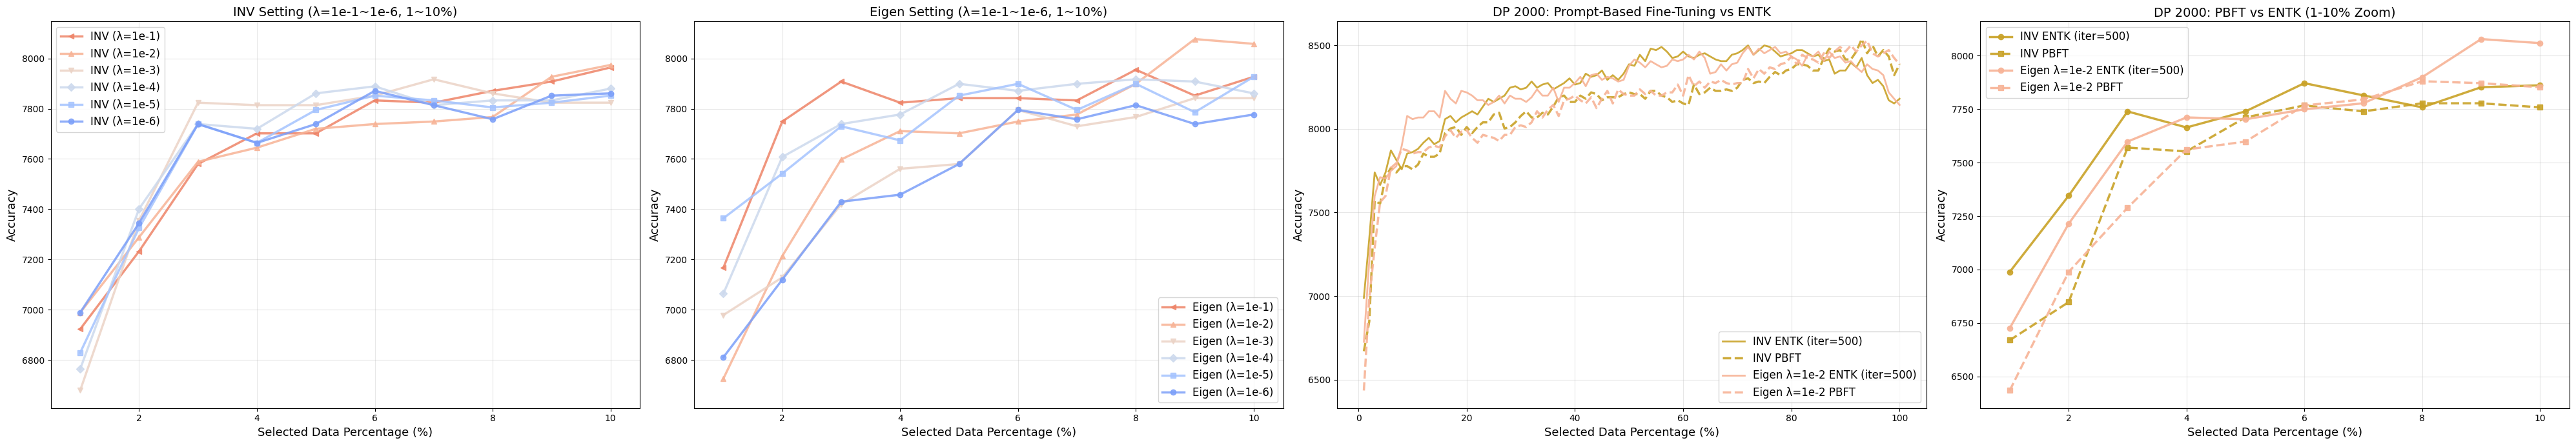

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6     = [6989, 7345, 7739, 7664, 7739, 7871, 7814, 7758, 7852, 7861, 7880, 7917, 7946, 7908, 7927, 8058, 8077, 8039, 8068, 8086, 8105, 8086, 8133, 8180, 8161, 8180, 8199, 8246, 8255, 8236, 8246, 8283, 8246, 8265, 8274, 8236, 8255, 8274, 8302, 8265, 8274, 8330, 8311, 8321, 8349, 8293, 8321, 8293, 8330, 8386, 8377, 8443, 8405, 8480, 8471, 8490, 8462, 8424, 8433, 8462, 8433, 8424, 8443, 8452, 8433, 8415, 8405, 8405, 8443, 8452, 8471, 8499, 8443, 8471, 8499, 8490, 8462, 8433, 8443, 8452, 8471, 8471, 8452, 8433, 8443, 8405, 8415, 8330, 8349, 8349, 8396, 8368, 8424, 8321, 8274, 8293, 8255, 8171, 8152, 8180]
inv_lam1e_5     = [6829, 7326, 7739, 7664, 7795, 7852, 7833, 7805, 7824, 7852, 7880, 7889, 7936, 7889, 7927, 8030, 8058, 8030, 8058, 8096, 8124, 8124, 8133, 8152, 8143, 8180, 8199, 8171, 8218, 8236, 8227, 8255, 8246, 8283, 8255, 8255, 8283, 8265, 8302, 8302, 8274, 8330, 8293, 8302, 8311, 8302, 8302, 8321, 8349, 8368, 8424, 8424, 8424, 8480, 8452, 8452, 8471, 8443, 8433, 8443, 8443, 8443, 8452, 8424, 8415, 8405, 8405, 8433, 8424, 8433, 8433, 8471, 8443, 8443, 8471, 8490, 8462, 8424, 8424, 8471, 8471, 8462, 8452, 8490, 8443, 8405, 8405, 8340, 8349, 8349, 8358, 8405, 8424, 8349, 8274, 8293, 8246, 8133, 8152, 8180]
inv_lam1e_4     = [6764, 7402, 7739, 7720, 7861, 7889, 7814, 7833, 7833, 7880, 7852, 7814, 7908, 7908, 7917, 7955, 8058, 8058, 8058, 8077, 8077, 8077, 8171, 8152, 8152, 8124, 8171, 8189, 8199, 8246, 8255, 8302, 8293, 8227, 8236, 8274, 8265, 8274, 8293, 8283, 8311, 8321, 8330, 8311, 8265, 8321, 8321, 8386, 8396, 8368, 8405, 8396, 8471, 8490, 8433, 8415, 8415, 8433, 8433, 8452, 8452, 8396, 8480, 8424, 8396, 8396, 8433, 8424, 8424, 8433, 8424, 8433, 8471, 8433, 8433, 8443, 8443, 8443, 8471, 8480, 8480, 8462, 8452, 8462, 8424, 8405, 8405, 8358, 8386, 8340, 8424, 8386, 8368, 8368, 8265, 8283, 8246, 8189, 8152, 8180]
inv_lam1e_3     = [6679, 7355, 7824, 7814, 7814, 7852, 7917, 7861, 7824, 7824, 7814, 7833, 7861, 7861, 7908, 7964, 8002, 8002, 8030, 8039, 8039, 8049, 8105, 8143, 8114, 8143, 8143, 8180, 8208, 8189, 8227, 8274, 8321, 8321, 8302, 8321, 8321, 8349, 8340, 8321, 8321, 8386, 8340, 8330, 8330, 8311, 8340, 8368, 8405, 8433, 8386, 8396, 8377, 8386, 8405, 8424, 8377, 8377, 8405, 8415, 8452, 8462, 8508, 8462, 8443, 8499, 8490, 8518, 8499, 8462, 8490, 8480, 8452, 8490, 8443, 8480, 8415, 8424, 8415, 8443, 8462, 8443, 8443, 8433, 8452, 8377, 8433, 8368, 8396, 8368, 8340, 8368, 8386, 8302, 8274, 8274, 8246, 8161, 8152, 8199]
inv_lam1e_2     = [6989, 7289, 7589, 7645, 7720, 7739, 7749, 7767, 7927, 7974, 7955, 7964, 8021, 8002, 7983, 7983, 8030, 8124, 8096, 8068, 8114, 8068, 8086, 8077, 8124, 8189, 8189, 8236, 8246, 8255, 8199, 8246, 8208, 8236, 8246, 8246, 8311, 8311, 8396, 8377, 8405, 8424, 8405, 8415, 8424, 8396, 8386, 8368, 8368, 8368, 8368, 8349, 8302, 8340, 8349, 8377, 8349, 8405, 8405, 8424, 8405, 8405, 8386, 8415, 8396, 8405, 8480, 8452, 8405, 8452, 8443, 8415, 8433, 8433, 8471, 8433, 8443, 8433, 8480, 8452, 8433, 8424, 8377, 8386, 8405, 8424, 8424, 8377, 8396, 8368, 8302, 8405, 8386, 8265, 8311, 8265, 8208, 8171, 8189, 8180]
inv_lam1e_1     = [6923, 7233, 7580, 7702, 7702, 7833, 7824, 7871, 7908, 7964, 7964, 7992, 8021, 8002, 8002, 8030, 8068, 8124, 8161, 8143, 8124, 8143, 8171, 8199, 8218, 8246, 8274, 8227, 8274, 8274, 8246, 8208, 8218, 8236, 8218, 8236, 8218, 8246, 8227, 8293, 8265, 8255, 8236, 8208, 8218, 8227, 8265, 8265, 8330, 8302, 8311, 8386, 8349, 8340, 8330, 8349, 8368, 8368, 8377, 8415, 8452, 8386, 8377, 8424, 8443, 8443, 8471, 8433, 8443, 8452, 8499, 8490, 8480, 8471, 8424, 8452, 8471, 8480, 8480, 8527, 8471, 8546, 8527, 8462, 8471, 8471, 8471, 8480, 8462, 8471, 8396, 8452, 8471, 8386, 8386, 8368, 8265, 8255, 8321, 8218]
eigen_lam1e_6   = [6811, 7120, 7430, 7458, 7580, 7795, 7758, 7814, 7739, 7777, 7852, 7936, 7936, 8002, 7974, 7964, 7946, 7974, 7833, 7861, 7814, 7777, 7767, 7739, 7749, 7702, 7645, 7083, 6548, 5994, 6623, 6961, 7223, 7280, 7420, 7795, 7964, 8002, 8002, 8114, 8058, 8068, 8143, 8105, 8077, 8189, 8086, 8133, 8152, 8180, 8227, 8227, 8227, 8265, 8218, 8321, 8340, 8311, 8302, 8349, 8349, 8293, 8330, 8386, 8396, 8424, 8443, 8433, 8480, 8443, 8415, 8415, 8424, 8405, 8424, 8386, 8340, 8340, 8415, 8443, 8452, 8377, 8349, 8340, 8358, 8340, 8311, 8358, 8311, 8283, 8330, 8368, 8293, 8321, 8293, 8227, 8246, 8189, 8208, 8161]
eigen_lam1e_5   = [7364, 7542, 7730, 7674, 7852, 7899, 7795, 7899, 7786, 7927, 7946, 7964, 7964, 8002, 8039, 8021, 7974, 7936, 7749, 7786, 7824, 7842, 7824, 7786, 7674, 7420, 7402, 7420, 7251, 7054, 6961, 7214, 7111, 7674, 7824, 8049, 8021, 7946, 7946, 7983, 8049, 8124, 8133, 8096, 8208, 8199, 8143, 8227, 8246, 8265, 8311, 8321, 8255, 8330, 8386, 8340, 8424, 8424, 8405, 8415, 8443, 8396, 8377, 8424, 8424, 8396, 8340, 8321, 8340, 8368, 8302, 8293, 8330, 8330, 8358, 8368, 8340, 8386, 8415, 8330, 8349, 8377, 8321, 8368, 8405, 8386, 8349, 8349, 8358, 8377, 8340, 8311, 8349, 8311, 8255, 8227, 8227, 8218, 8171, 8161]
eigen_lam1e_4   = [7064, 7608, 7739, 7777, 7899, 7871, 7899, 7917, 7908, 7861, 7936, 7871, 7908, 7983, 8039, 8039, 8039, 8068, 8021, 8077, 8049, 7917, 7861, 7908, 7739, 7617, 7589, 7655, 7580, 7683, 7720, 7833, 7842, 7739, 7805, 7871, 7974, 8021, 8039, 8114, 8255, 8255, 8321, 8246, 8199, 8218, 8199, 8265, 8274, 8274, 8255, 8255, 8255, 8302, 8302, 8274, 8321, 8265, 8302, 8349, 8340, 8368, 8377, 8415, 8377, 8330, 8340, 8368, 8349, 8396, 8377, 8368, 8368, 8330, 8340, 8396, 8321, 8340, 8330, 8311, 8377, 8330, 8405, 8405, 8443, 8405, 8415, 8349, 8358, 8311, 8311, 8265, 8283, 8283, 8293, 8227, 8255, 8265, 8199, 8161]
eigen_lam1e_3   = [6979, 7129, 7420, 7561, 7580, 7795, 7730, 7767, 7842, 7842, 7889, 7983, 7992, 8058, 8039, 8030, 7983, 7946, 7936, 7833, 7842, 7777, 7842, 7861, 7917, 7936, 7936, 7927, 7974, 8002, 7955, 8049, 8068, 8002, 8068, 8133, 8030, 8049, 8086, 8199, 8152, 8105, 8161, 8161, 8171, 8283, 8208, 8199, 8265, 8218, 8274, 8227, 8265, 8302, 8283, 8321, 8330, 8255, 8340, 8358, 8462, 8396, 8386, 8415, 8405, 8386, 8321, 8340, 8302, 8274, 8302, 8386, 8330, 8321, 8321, 8330, 8377, 8330, 8396, 8386, 8386, 8415, 8368, 8377, 8396, 8377, 8405, 8405, 8368, 8349, 8424, 8358, 8340, 8321, 8293, 8274, 8293, 8283, 8180, 8152]
eigen_lam1e_2   = [6726, 7214, 7598, 7711, 7702, 7749, 7777, 7899, 8077, 8058, 8068, 8068, 8105, 8105, 8068, 8227, 8180, 8152, 8227, 8218, 8199, 8171, 8171, 8143, 8161, 8199, 8152, 8199, 8180, 8180, 8161, 8189, 8236, 8199, 8199, 8246, 8161, 8246, 8246, 8274, 8311, 8255, 8321, 8330, 8293, 8311, 8302, 8283, 8293, 8377, 8415, 8396, 8368, 8405, 8386, 8368, 8377, 8415, 8405, 8415, 8443, 8415, 8462, 8424, 8330, 8340, 8386, 8349, 8386, 8396, 8452, 8490, 8443, 8480, 8452, 8471, 8490, 8452, 8462, 8433, 8415, 8377, 8443, 8433, 8462, 8405, 8462, 8424, 8433, 8396, 8405, 8368, 8340, 8386, 8358, 8349, 8321, 8218, 8180, 8143]
eigen_lam1e_1   = [7167, 7749, 7908, 7824, 7842, 7842, 7833, 7955, 7852, 7927, 7974, 7992, 8011, 8030, 8030, 8030, 8086, 8105, 8086, 8114, 8096, 8152, 8171, 8208, 8218, 8143, 8171, 8161, 8208, 8180, 8180, 8208, 8152, 8161, 8208, 8218, 8218, 8180, 8180, 8236, 8199, 8161, 8227, 8227, 8255, 8265, 8265, 8246, 8283, 8302, 8283, 8302, 8330, 8330, 8349, 8340, 8349, 8330, 8311, 8311, 8321, 8302, 8330, 8283, 8311, 8302, 8349, 8377, 8377, 8340, 8349, 8396, 8433, 8433, 8443, 8443, 8405, 8443, 8424, 8415, 8415, 8377, 8396, 8443, 8396, 8405, 8415, 8433, 8424, 8452, 8415, 8368, 8377, 8349, 8368, 8358, 8340, 8311, 8293, 8171]

# Prediction with random shapley values
r_inv_lam1e_6   = [6116, 7205, 7364, 7233, 7242, 7420, 7467, 7598, 7608, 7580, 7561, 7580, 7570, 7552, 7645, 7542, 7711, 7655, 7749, 7711, 7795, 7777, 7720, 7645, 7720, 7739, 7767, 7767, 7702, 7739, 7767, 7777, 7842, 7786, 7824, 7805, 7908, 7908, 7946, 7908, 7842, 7833, 7880, 7852, 7889, 7899, 7871, 7871, 7871, 7899, 7899, 7889, 7795, 7852, 7805, 7814, 7805, 7824, 7899, 7946, 7946, 8011, 7936, 7946, 7927, 7899, 7946, 7917, 7974, 7974, 7917, 7936, 7992, 7955, 7936, 7992, 7964, 7992, 7983, 7974, 8030, 8002, 8002, 8039, 7955, 7983, 8002, 8011, 8030, 7983, 8030, 8077, 8021, 8039, 8105, 8152, 8105, 8152, 8133, 8180]
r_inv_lam1e_5   = [6116, 7205, 7364, 7233, 7242, 7420, 7467, 7598, 7608, 7580, 7561, 7580, 7570, 7552, 7645, 7542, 7711, 7655, 7749, 7711, 7795, 7777, 7720, 7645, 7720, 7739, 7767, 7767, 7702, 7739, 7767, 7777, 7842, 7786, 7824, 7805, 7908, 7908, 7946, 7908, 7842, 7833, 7880, 7852, 7889, 7899, 7871, 7871, 7871, 7899, 7899, 7899, 7795, 7852, 7805, 7814, 7805, 7824, 7899, 7946, 7946, 8011, 7936, 7946, 7927, 7899, 7946, 7917, 7974, 7974, 7917, 7936, 7992, 7955, 7936, 7992, 7964, 7992, 7983, 7974, 8030, 8002, 8002, 8039, 7955, 7983, 8002, 8011, 8030, 7983, 8030, 8077, 8021, 8039, 8105, 8152, 8105, 8152, 8133, 8180]
r_inv_lam1e_4   = [6116, 7205, 7364, 7233, 7242, 7420, 7477, 7598, 7608, 7580, 7561, 7570, 7570, 7552, 7645, 7542, 7711, 7655, 7749, 7711, 7795, 7777, 7720, 7645, 7720, 7730, 7767, 7767, 7702, 7749, 7767, 7777, 7842, 7786, 7824, 7805, 7908, 7908, 7946, 7908, 7842, 7833, 7880, 7852, 7889, 7899, 7871, 7871, 7871, 7899, 7899, 7899, 7795, 7852, 7805, 7814, 7805, 7824, 7899, 7946, 7946, 8002, 7946, 7946, 7927, 7899, 7946, 7917, 7983, 7974, 7917, 7936, 7992, 7955, 7936, 7992, 7964, 7992, 7983, 7974, 8030, 8011, 8002, 8049, 7955, 7983, 8002, 8011, 8030, 7983, 8039, 8086, 8021, 8039, 8105, 8152, 8105, 8152, 8152, 8180]
r_inv_lam1e_3   = [6116, 7195, 7364, 7233, 7242, 7420, 7486, 7598, 7617, 7580, 7570, 7570, 7570, 7561, 7655, 7533, 7720, 7664, 7730, 7730, 7786, 7777, 7720, 7655, 7739, 7739, 7758, 7767, 7692, 7767, 7767, 7767, 7833, 7777, 7833, 7824, 7908, 7917, 7946, 7908, 7842, 7842, 7880, 7852, 7899, 7889, 7880, 7861, 7861, 7889, 7889, 7899, 7795, 7861, 7824, 7824, 7795, 7842, 7908, 7955, 7927, 7992, 7946, 7946, 7927, 7908, 7946, 7908, 7992, 7974, 7917, 7908, 7992, 7955, 7927, 8002, 7983, 7992, 7983, 7964, 8039, 8021, 8002, 8039, 7974, 7983, 8011, 8021, 8039, 7983, 8039, 8086, 8030, 8039, 8105, 8143, 8096, 8152, 8143, 8199]
r_inv_lam1e_2   = [6126, 7186, 7373, 7214, 7242, 7439, 7495, 7608, 7627, 7617, 7589, 7570, 7580, 7598, 7655, 7589, 7739, 7664, 7730, 7749, 7795, 7805, 7749, 7702, 7777, 7739, 7767, 7767, 7730, 7786, 7824, 7824, 7852, 7824, 7852, 7889, 7936, 7917, 7974, 7936, 7880, 7880, 7927, 7889, 7899, 7927, 7927, 7889, 7880, 7899, 7927, 7871, 7852, 7861, 7833, 7861, 7852, 7880, 7917, 7964, 7955, 8002, 7927, 7974, 7908, 7974, 7964, 7955, 8030, 8021, 7946, 7936, 8021, 7983, 7946, 7992, 7983, 8021, 8068, 8002, 8039, 8030, 8058, 8068, 7974, 8002, 8077, 8058, 8049, 8077, 8049, 8133, 8114, 8105, 8161, 8161, 8124, 8180, 8143, 8180]
r_inv_lam1e_1   = [6060, 7186, 7411, 7280, 7280, 7505, 7552, 7598, 7664, 7720, 7674, 7692, 7720, 7655, 7777, 7777, 7852, 7861, 7852, 7786, 7889, 7880, 7833, 7786, 7871, 7833, 7824, 7805, 7814, 7842, 7842, 7899, 7964, 7917, 7946, 8030, 8068, 8161, 8189, 8143, 8152, 8124, 8171, 8143, 8180, 8143, 8096, 8096, 8124, 8096, 8096, 8068, 8030, 8096, 8011, 8049, 8058, 8058, 8068, 8114, 8143, 8143, 8105, 8180, 8143, 8180, 8171, 8180, 8161, 8096, 8096, 8133, 8143, 8077, 8096, 8096, 8114, 8133, 8171, 8180, 8161, 8189, 8161, 8152, 8246, 8161, 8208, 8171, 8227, 8283, 8246, 8255, 8246, 8227, 8227, 8265, 8236, 8246, 8283, 8218]
r_eigen_lam1e_6 = [6032, 7054, 7261, 6820, 7008, 7129, 7120, 7158, 7111, 7176, 7045, 7111, 6998, 6932, 6914, 6951, 7045, 7111, 7045, 6979, 6801, 6867, 6726, 6501, 6482, 6492, 6238, 6229, 5647, 5769, 5854, 5966, 6079, 5882, 6182, 6492, 6717, 7054, 7129, 7270, 7111, 7148, 7148, 7233, 7158, 7383, 7308, 7364, 7345, 7402, 7458, 7402, 7448, 7561, 7617, 7636, 7664, 7645, 7655, 7711, 7842, 7805, 7871, 7899, 7946, 8002, 8021, 7946, 8077, 8030, 7983, 7983, 8039, 8058, 8068, 8058, 8096, 8039, 8086, 7983, 8030, 8058, 8058, 8086, 8077, 8133, 8049, 8096, 8105, 8086, 8096, 8133, 8180, 8152, 8133, 8124, 8171, 8171, 8105, 8161]
r_eigen_lam1e_5 = [6098, 7064, 7298, 6820, 6989, 7120, 7092, 7186, 7148, 7176, 7054, 7148, 7026, 6961, 6914, 6989, 7083, 7111, 7054, 7008, 6801, 6839, 6745, 6501, 6510, 6482, 6332, 6257, 5816, 5910, 5826, 5957, 6079, 5891, 6238, 6473, 6717, 7064, 7129, 7270, 7111, 7148, 7148, 7233, 7158, 7392, 7308, 7355, 7345, 7402, 7458, 7411, 7448, 7561, 7617, 7636, 7664, 7645, 7655, 7711, 7842, 7805, 7871, 7899, 7946, 8002, 8021, 7946, 8077, 8030, 7983, 7983, 8039, 8058, 8068, 8058, 8096, 8049, 8086, 7983, 8030, 8058, 8058, 8086, 8077, 8133, 8049, 8096, 8105, 8086, 8096, 8133, 8180, 8152, 8133, 8124, 8171, 8171, 8105, 8161]
r_eigen_lam1e_4 = [6079, 7073, 7298, 6811, 6970, 7111, 7120, 7195, 7176, 7176, 7073, 7139, 7017, 6961, 6942, 7008, 7073, 7101, 7064, 7008, 6811, 6876, 6754, 6557, 6604, 6585, 6548, 6435, 6238, 6135, 5947, 6088, 6248, 6069, 6248, 6567, 6782, 7073, 7148, 7289, 7120, 7167, 7176, 7261, 7205, 7392, 7308, 7355, 7364, 7402, 7430, 7420, 7448, 7542, 7617, 7645, 7655, 7645, 7655, 7711, 7842, 7805, 7871, 7899, 7946, 8002, 8021, 7946, 8077, 8021, 7983, 7983, 8039, 8058, 8068, 8058, 8096, 8049, 8086, 7983, 8030, 8058, 8058, 8086, 8077, 8133, 8049, 8096, 8105, 8077, 8096, 8133, 8180, 8152, 8143, 8124, 8171, 8171, 8105, 8161]
r_eigen_lam1e_3 = [6079, 7073, 7317, 6811, 6998, 7111, 7139, 7233, 7167, 7195, 7120, 7167, 7008, 6989, 7064, 7054, 7167, 7242, 7223, 7195, 7083, 6970, 6942, 6886, 6942, 6961, 7139, 6895, 6857, 6679, 6745, 6670, 6820, 6782, 6932, 6923, 7083, 7129, 7261, 7383, 7364, 7308, 7355, 7364, 7186, 7439, 7420, 7458, 7477, 7430, 7458, 7477, 7495, 7598, 7645, 7683, 7664, 7655, 7683, 7730, 7871, 7842, 7861, 7908, 7927, 8002, 8021, 7946, 8086, 8021, 7983, 7974, 8039, 8086, 8077, 8077, 8124, 8039, 8105, 7992, 8030, 8068, 8068, 8096, 8077, 8133, 8058, 8096, 8114, 8077, 8096, 8133, 8189, 8152, 8152, 8133, 8171, 8171, 8105, 8152]
r_eigen_lam1e_2 = [6088, 7083, 7308, 6857, 7026, 7158, 7289, 7355, 7373, 7355, 7298, 7411, 7326, 7280, 7420, 7308, 7420, 7523, 7598, 7542, 7561, 7523, 7373, 7402, 7486, 7542, 7458, 7486, 7364, 7392, 7467, 7505, 7514, 7448, 7439, 7345, 7561, 7617, 7683, 7664, 7636, 7664, 7664, 7711, 7636, 7702, 7720, 7749, 7674, 7674, 7814, 7805, 7777, 7899, 7805, 7833, 7889, 7880, 7899, 7927, 8021, 7964, 7992, 8030, 8086, 8002, 8086, 8077, 8133, 8096, 7955, 8021, 8068, 8105, 8058, 8058, 8133, 8105, 8096, 8049, 8021, 8096, 8105, 8143, 8133, 8143, 8077, 8096, 8114, 8143, 8133, 8124, 8171, 8171, 8189, 8152, 8152, 8171, 8124, 8143]
r_eigen_lam1e_1 = [6069, 7148, 7364, 7205, 7233, 7439, 7533, 7561, 7627, 7655, 7636, 7608, 7580, 7608, 7720, 7655, 7767, 7805, 7861, 7814, 7880, 7871, 7852, 7767, 7805, 7795, 7786, 7795, 7739, 7805, 7842, 7842, 7946, 7889, 7936, 7927, 8011, 8068, 8021, 8030, 8086, 8068, 8105, 8068, 8058, 8114, 8068, 8096, 8077, 8068, 8114, 8105, 8096, 8114, 8105, 8124, 8068, 8133, 8086, 8161, 8171, 8189, 8143, 8199, 8143, 8143, 8199, 8208, 8265, 8255, 8218, 8218, 8171, 8218, 8208, 8208, 8227, 8189, 8227, 8208, 8189, 8218, 8218, 8180, 8180, 8208, 8152, 8171, 8171, 8218, 8208, 8265, 8236, 8218, 8208, 8171, 8180, 8208, 8161, 8171]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = [6670, 6848, 7570, 7552, 7711, 7767, 7739, 7777, 7777, 7758, 7786, 7852, 7833, 7833, 7852, 7974, 8002, 8011, 7964, 8011, 7974, 8011, 8039, 8039, 8086, 8096, 8002, 8011, 8039, 8077, 8105, 8068, 8068, 8096, 8086, 8133, 8189, 8199, 8161, 8161, 8199, 8180, 8218, 8208, 8171, 8189, 8189, 8189, 8208, 8218, 8208, 8208, 8180, 8227, 8227, 8199, 8189, 8161, 8171, 8152, 8143, 8265, 8208, 8218, 8246, 8227, 8227, 8236, 8227, 8246, 8293, 8302, 8274, 8283, 8274, 8311, 8340, 8321, 8349, 8358, 8386, 8386, 8377, 8349, 8349, 8424, 8480, 8462, 8471, 8415, 8415, 8462, 8537, 8452, 8499, 8433, 8471, 8433, 8321, 8386]
pbft_eigen_lam1e_2 = [6435, 6989, 7289, 7561, 7598, 7767, 7795, 7880, 7871, 7852, 7861, 7861, 7889, 7899, 7889, 7955, 7992, 7946, 7983, 7992, 7946, 7917, 7964, 7955, 7946, 7927, 7964, 7964, 8011, 8021, 8011, 8039, 8105, 8068, 8114, 8143, 8077, 8171, 8180, 8199, 8171, 8152, 8189, 8124, 8180, 8227, 8152, 8236, 8208, 8199, 8199, 8236, 8208, 8227, 8199, 8199, 8218, 8218, 8265, 8199, 8321, 8255, 8283, 8246, 8283, 8274, 8293, 8274, 8265, 8274, 8274, 8358, 8302, 8358, 8330, 8368, 8358, 8386, 8396, 8433, 8386, 8443, 8424, 8415, 8396, 8452, 8424, 8462, 8490, 8462, 8499, 8462, 8499, 8527, 8452, 8433, 8452, 8471, 8424, 8386]
pbft_eigen_lam1e_1 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1-10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    # Set x-axis limit from 0.5 to 10.5 to focus on 1-10%
    ax_zoom.set_xlim(0.5, 10.5)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # If no PBFT data, hide the subplot
    ax_zoom.axis('off')
    ax_zoom.text(0.5, 0.5, 'No PBFT Data Available', 
                 ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()

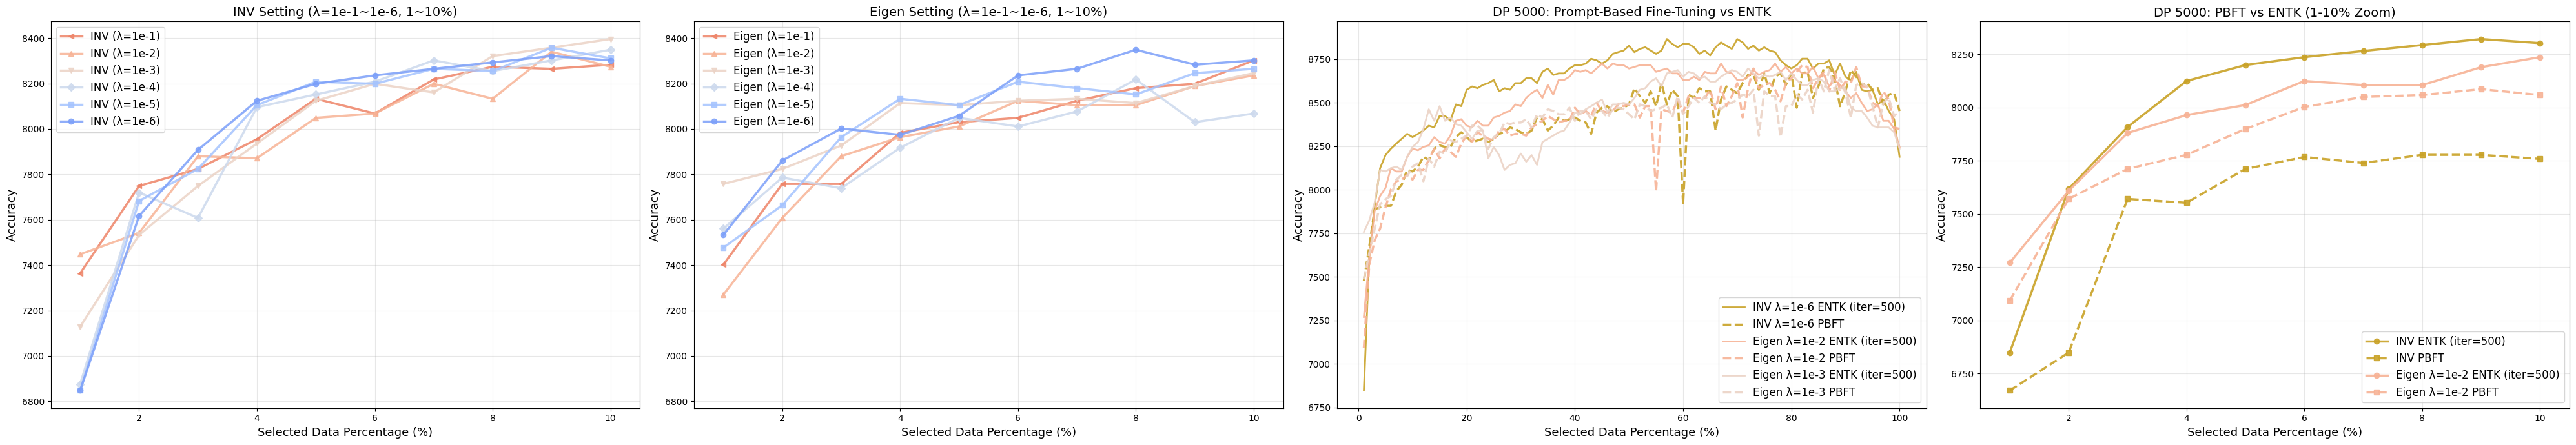

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6     = [6848, 7617, 7908, 8124, 8199, 8236, 8265, 8293, 8321, 8302, 8321, 8340, 8368, 8358, 8424, 8424, 8396, 8490, 8480, 8574, 8593, 8583, 8602, 8612, 8630, 8565, 8583, 8574, 8612, 8612, 8640, 8640, 8612, 8677, 8696, 8659, 8668, 8668, 8696, 8715, 8715, 8724, 8752, 8743, 8724, 8743, 8780, 8790, 8799, 8827, 8790, 8809, 8818, 8799, 8780, 8799, 8865, 8837, 8818, 8837, 8837, 8818, 8780, 8799, 8771, 8818, 8846, 8827, 8809, 8865, 8846, 8809, 8827, 8799, 8818, 8799, 8790, 8743, 8715, 8696, 8715, 8752, 8752, 8696, 8724, 8724, 8743, 8659, 8724, 8649, 8630, 8677, 8574, 8565, 8574, 8490, 8518, 8452, 8405, 8189]
inv_lam1e_5     = [6848, 7683, 7824, 8105, 8208, 8199, 8265, 8255, 8358, 8311, 8321, 8358, 8358, 8424, 8415, 8480, 8480, 8490, 8480, 8537, 8583, 8612, 8630, 8593, 8612, 8565, 8583, 8565, 8593, 8640, 8640, 8630, 8659, 8677, 8649, 8677, 8687, 8687, 8696, 8696, 8705, 8724, 8696, 8696, 8743, 8724, 8762, 8799, 8818, 8837, 8827, 8809, 8780, 8818, 8799, 8790, 8818, 8827, 8856, 8809, 8856, 8827, 8827, 8827, 8752, 8818, 8818, 8818, 8837, 8856, 8865, 8846, 8809, 8790, 8780, 8790, 8799, 8743, 8743, 8715, 8696, 8743, 8752, 8743, 8734, 8715, 8752, 8668, 8668, 8696, 8659, 8715, 8574, 8593, 8583, 8527, 8490, 8480, 8386, 8189] 
inv_lam1e_4     = [6876, 7720, 7608, 8096, 8152, 8208, 8302, 8255, 8302, 8349, 8274, 8340, 8368, 8386, 8443, 8443, 8480, 8508, 8574, 8555, 8527, 8565, 8546, 8612, 8593, 8583, 8612, 8612, 8612, 8630, 8612, 8612, 8602, 8612, 8630, 8668, 8659, 8677, 8659, 8705, 8677, 8687, 8715, 8724, 8734, 8734, 8771, 8799, 8809, 8799, 8809, 8780, 8771, 8790, 8790, 8809, 8790, 8790, 8780, 8818, 8752, 8809, 8837, 8846, 8827, 8856, 8809, 8809, 8827, 8809, 8856, 8856, 8827, 8790, 8762, 8809, 8780, 8743, 8752, 8696, 8696, 8715, 8734, 8752, 8762, 8752, 8715, 8677, 8640, 8640, 8696, 8677, 8602, 8565, 8593, 8555, 8508, 8452, 8396, 8189]  
inv_lam1e_3     = [7129, 7533, 7749, 7936, 8124, 8199, 8161, 8321, 8358, 8396, 8349, 8321, 8424, 8405, 8443, 8499, 8527, 8508, 8537, 8574, 8602, 8612, 8527, 8546, 8574, 8593, 8546, 8602, 8630, 8649, 8630, 8649, 8668, 8640, 8687, 8677, 8677, 8715, 8743, 8743, 8734, 8696, 8752, 8752, 8752, 8743, 8762, 8734, 8780, 8790, 8762, 8771, 8724, 8752, 8734, 8762, 8771, 8780, 8762, 8771, 8752, 8743, 8762, 8771, 8790, 8809, 8837, 8818, 8780, 8818, 8809, 8818, 8827, 8809, 8827, 8809, 8762, 8762, 8771, 8790, 8771, 8762, 8752, 8771, 8762, 8771, 8752, 8734, 8668, 8677, 8687, 8668, 8677, 8630, 8546, 8537, 8490, 8508, 8405, 8218] 
inv_lam1e_2     = [7448, 7542, 7880, 7871, 8049, 8068, 8199, 8133, 8340, 8274, 8330, 8321, 8349, 8340, 8377, 8386, 8452, 8462, 8490, 8555, 8537, 8565, 8565, 8640, 8630, 8705, 8705, 8668, 8724, 8724, 8762, 8734, 8743, 8743, 8724, 8734, 8743, 8780, 8771, 8818, 8827, 8734, 8743, 8780, 8799, 8818, 8799, 8818, 8818, 8743, 8818, 8865, 8893, 8837, 8827, 8809, 8790, 8809, 8762, 8790, 8846, 8846, 8865, 8856, 8884, 8856, 8827, 8837, 8809, 8790, 8780, 8799, 8799, 8771, 8790, 8780, 8780, 8771, 8762, 8799, 8799, 8809, 8771, 8799, 8780, 8743, 8724, 8715, 8743, 8780, 8724, 8696, 8687, 8677, 8640, 8583, 8555, 8480, 8396, 8265]     
inv_lam1e_1     = [7364, 7749, 7824, 7955, 8133, 8068, 8218, 8274, 8265, 8283, 8208, 8274, 8330, 8405, 8415, 8386, 8358, 8443, 8490, 8490, 8518, 8565, 8555, 8574, 8574, 8593, 8640, 8621, 8630, 8640, 8649, 8705, 8705, 8668, 8715, 8677, 8705, 8705, 8724, 8715, 8743, 8724, 8715, 8715, 8734, 8752, 8771, 8790, 8780, 8809, 8827, 8827, 8818, 8790, 8818, 8780, 8799, 8799, 8771, 8762, 8771, 8771, 8762, 8752, 8790, 8780, 8799, 8846, 8837, 8809, 8809, 8771, 8780, 8790, 8743, 8818, 8846, 8809, 8762, 8799, 8734, 8780, 8762, 8752, 8715, 8715, 8715, 8724, 8771, 8752, 8752, 8734, 8715, 8677, 8705, 8659, 8612, 8527, 8471, 8386]  
eigen_lam1e_6   = [7533, 7861, 8002, 7974, 8058, 8236, 8265, 8349, 8283, 8302, 8330, 8180, 8236, 8227, 8246, 8208, 8180, 8265, 8189, 8161, 8152, 8096, 7964, 7880, 7786, 7692, 7749, 7308, 6801, 5854, 6445, 6932, 7392, 7505, 7702, 8021, 7927, 8189, 8283, 8180, 8236, 8302, 8255, 8274, 8311, 8340, 8358, 8377, 8358, 8396, 8424, 8415, 8415, 8555, 8537, 8555, 8649, 8612, 8649, 8649, 8687, 8640, 8677, 8659, 8630, 8612, 8630, 8565, 8518, 8565, 8593, 8602, 8593, 8593, 8583, 8640, 8612, 8640, 8687, 8668, 8612, 8583, 8574, 8518, 8583, 8508, 8546, 8499, 8527, 8527, 8480, 8405, 8396, 8358, 8424, 8377, 8433, 8386, 8340, 8236]
eigen_lam1e_5   = [7477, 7664, 7964, 8133, 8105, 8208, 8180, 8152, 8246, 8265, 8218, 8321, 8274, 8311, 8236, 8227, 8236, 8246, 8246, 8199, 8227, 8208, 8086, 7814, 7627, 7542, 7458, 7214, 6735, 6576, 6914, 7373, 7702, 7702, 7871, 8021, 7974, 7908, 8011, 8049, 8283, 8255, 8330, 8377, 8368, 8349, 8424, 8490, 8499, 8499, 8593, 8565, 8565, 8583, 8555, 8593, 8527, 8518, 8555, 8583, 8565, 8621, 8640, 8593, 8602, 8630, 8649, 8649, 8574, 8640, 8630, 8602, 8593, 8574, 8555, 8565, 8565, 8574, 8583, 8640, 8659, 8630, 8593, 8565, 8555, 8546, 8565, 8518, 8555, 8565, 8527, 8518, 8471, 8433, 8480, 8424, 8396, 8368, 8368, 8236]
eigen_lam1e_4   = [7561, 7786, 7739, 7917, 8049, 8011, 8077, 8218, 8030, 8068, 8086, 8114, 8077, 8096, 8236, 8199, 8227, 8358, 8311, 8218, 8236, 8208, 8274, 8114, 8068, 7964, 7936, 7908, 7739, 7786, 7955, 7861, 7908, 7899, 7917, 7955, 8161, 8189, 8274, 8349, 8321, 8283, 8302, 8349, 8396, 8405, 8471, 8583, 8527, 8518, 8574, 8621, 8565, 8499, 8537, 8537, 8574, 8555, 8593, 8527, 8537, 8499, 8593, 8574, 8537, 8583, 8574, 8630, 8621, 8659, 8659, 8621, 8649, 8621, 8602, 8640, 8583, 8593, 8583, 8583, 8555, 8499, 8518, 8602, 8565, 8574, 8527, 8490, 8480, 8490, 8537, 8518, 8471, 8386, 8386, 8358, 8377, 8330, 8358, 8236]
eigen_lam1e_3   = [7758, 7824, 7927, 8114, 8105, 8124, 8133, 8114, 8189, 8246, 8274, 8349, 8462, 8396, 8480, 8396, 8415, 8377, 8368, 8330, 8293, 8340, 8340, 8180, 8246, 8199, 8114, 8143, 8152, 8208, 8161, 8199, 8143, 8274, 8293, 8311, 8330, 8340, 8386, 8443, 8433, 8462, 8480, 8499, 8518, 8443, 8490, 8490, 8499, 8490, 8527, 8574, 8583, 8621, 8640, 8593, 8668, 8677, 8687, 8649, 8677, 8668, 8640, 8649, 8621, 8621, 8649, 8668, 8687, 8677, 8649, 8696, 8668, 8640, 8659, 8649, 8659, 8677, 8630, 8668, 8630, 8602, 8602, 8630, 8640, 8621, 8565, 8565, 8583, 8583, 8471, 8452, 8452, 8415, 8368, 8358, 8358, 8358, 8330, 8236]
eigen_lam1e_2   = [7270, 7608, 7880, 7964, 8011, 8124, 8105, 8105, 8189, 8236, 8227, 8246, 8255, 8302, 8274, 8265, 8311, 8396, 8405, 8368, 8358, 8396, 8368, 8368, 8415, 8424, 8443, 8452, 8490, 8480, 8527, 8555, 8574, 8527, 8602, 8546, 8630, 8630, 8649, 8687, 8677, 8687, 8668, 8696, 8724, 8696, 8724, 8715, 8715, 8696, 8705, 8715, 8715, 8715, 8677, 8687, 8696, 8668, 8668, 8630, 8630, 8649, 8630, 8677, 8668, 8668, 8724, 8677, 8668, 8630, 8630, 8649, 8687, 8659, 8677, 8687, 8724, 8677, 8705, 8668, 8696, 8668, 8668, 8705, 8640, 8659, 8593, 8630, 8602, 8565, 8527, 8555, 8499, 8452, 8462, 8490, 8396, 8396, 8349, 8246]
eigen_lam1e_1   = [7402, 7758, 7758, 7983, 8030, 8049, 8124, 8180, 8199, 8302, 8274, 8377, 8405, 8424, 8480, 8443, 8452, 8471, 8452, 8527, 8490, 8508, 8518, 8527, 8527, 8518, 8565, 8546, 8527, 8527, 8546, 8527, 8527, 8574, 8555, 8583, 8621, 8602, 8612, 8630, 8612, 8630, 8677, 8649, 8621, 8640, 8649, 8659, 8659, 8677, 8659, 8668, 8696, 8677, 8677, 8724, 8724, 8724, 8696, 8705, 8696, 8696, 8668, 8677, 8687, 8696, 8715, 8696, 8687, 8677, 8705, 8696, 8724, 8705, 8696, 8668, 8687, 8715, 8659, 8649, 8659, 8649, 8668, 8668, 8677, 8649, 8630, 8640, 8640, 8602, 8583, 8593, 8565, 8546, 8518, 8508, 8405, 8368, 8330, 8302]

# Prediction with random shapley values
r_inv_lam1e_6   = [6895, 7561, 7674, 7852, 7824, 7786, 7880, 7992, 8030, 7992, 8124, 8058, 7936, 8011, 8105, 8030, 8077, 8143, 8030, 7983, 7946, 8002, 7974, 7946, 8021, 8021, 8068, 7992, 8105, 8049, 8011, 8021, 8011, 8039, 7983, 7946, 8011, 8011, 8039, 7983, 8021, 8058, 7992, 8039, 8039, 8096, 8058, 7992, 8105, 8068, 7983, 8030, 8096, 8086, 8114, 8068, 8143, 8096, 8143, 8189, 8143, 8143, 8096, 8114, 8068, 8143, 8039, 8114, 8124, 8143, 8171, 8133, 8096, 8161, 8114, 8161, 8152, 8133, 8133, 8143, 8199, 8227, 8143, 8208, 8255, 8265, 8283, 8311, 8255, 8293, 8283, 8255, 8227, 8236, 8189, 8208, 8208, 8227, 8218, 8189]
r_inv_lam1e_5   = [6895, 7561, 7674, 7852, 7824, 7786, 7880, 7992, 8030, 7992, 8124, 8058, 7936, 8021, 8105, 8030, 8077, 8143, 8030, 7983, 7946, 8002, 7974, 7946, 8021, 8021, 8068, 7992, 8105, 8049, 8011, 8021, 8011, 8039, 7983, 7946, 8011, 8011, 8039, 7983, 8021, 8058, 7992, 8039, 8039, 8096, 8058, 7992, 8105, 8068, 7983, 8030, 8096, 8086, 8114, 8068, 8143, 8096, 8143, 8189, 8143, 8143, 8096, 8114, 8068, 8143, 8039, 8114, 8124, 8143, 8171, 8133, 8096, 8161, 8114, 8161, 8152, 8133, 8133, 8143, 8199, 8227, 8143, 8208, 8255, 8265, 8283, 8311, 8255, 8293, 8283, 8255, 8227, 8236, 8189, 8208, 8208, 8227, 8218, 8189]                                
r_inv_lam1e_4   = [6895, 7561, 7674, 7852, 7824, 7786, 7880, 7992, 8039, 7992, 8124, 8058, 7936, 8021, 8114, 8030, 8077, 8143, 8030, 7983, 7946, 8002, 7974, 7946, 8021, 8021, 8068, 7992, 8105, 8049, 8011, 8021, 8011, 8039, 7983, 7946, 8002, 8011, 8039, 7983, 8021, 8058, 8002, 8039, 8039, 8096, 8058, 7992, 8105, 8068, 7974, 8030, 8096, 8086, 8114, 8068, 8143, 8096, 8143, 8199, 8143, 8152, 8096, 8114, 8068, 8143, 8049, 8114, 8124, 8143, 8180, 8133, 8096, 8161, 8114, 8161, 8143, 8133, 8133, 8152, 8208, 8227, 8143, 8208, 8255, 8265, 8283, 8311, 8255, 8293, 8283, 8265, 8227, 8246, 8199, 8199, 8208, 8227, 8218, 8189]       
r_inv_lam1e_3   = [6886, 7570, 7683, 7861, 7842, 7795, 7880, 7992, 8049, 8002, 8143, 8058, 7946, 8030, 8124, 8030, 8086, 8133, 8030, 7992, 7946, 8002, 7964, 7946, 8011, 8039, 8068, 7992, 8105, 8058, 8011, 8030, 8011, 8039, 7964, 7955, 8002, 8021, 8039, 7983, 8039, 8030, 8011, 8058, 8049, 8105, 8068, 8002, 8096, 8058, 7983, 8039, 8086, 8077, 8124, 8068, 8133, 8077, 8133, 8208, 8152, 8152, 8105, 8114, 8077, 8161, 8068, 8114, 8133, 8152, 8180, 8143, 8096, 8171, 8124, 8171, 8152, 8161, 8152, 8152, 8208, 8218, 8152, 8199, 8255, 8265, 8283, 8321, 8265, 8274, 8302, 8274, 8227, 8255, 8199, 8208, 8208, 8218, 8208, 8218] 
r_inv_lam1e_2   = [6876, 7608, 7692, 7861, 7871, 7795, 7899, 8030, 8049, 7964, 8124, 8068, 8030, 8096, 8096, 8049, 8124, 8208, 8096, 8021, 8011, 7992, 7964, 8011, 8049, 8096, 8068, 8039, 8114, 8077, 8058, 7992, 8039, 8086, 8049, 8058, 8030, 8077, 8039, 7983, 8077, 8096, 8049, 8068, 8124, 8124, 8096, 8039, 8161, 8058, 8049, 8058, 8058, 8049, 8114, 8077, 8171, 8124, 8152, 8246, 8180, 8161, 8114, 8152, 8133, 8143, 8133, 8171, 8189, 8180, 8236, 8208, 8218, 8189, 8180, 8218, 8218, 8255, 8236, 8208, 8255, 8302, 8265, 8227, 8274, 8293, 8293, 8340, 8330, 8330, 8330, 8302, 8330, 8293, 8255, 8246, 8236, 8227, 8246, 8265]  
r_inv_lam1e_1   = [6792, 7889, 7889, 8039, 8030, 7964, 8039, 8124, 8152, 8143, 8152, 8180, 8218, 8180, 8133, 8199, 8208, 8302, 8171, 8180, 8133, 8124, 8143, 8161, 8199, 8171, 8180, 8180, 8180, 8227, 8218, 8227, 8255, 8218, 8161, 8161, 8199, 8199, 8218, 8208, 8199, 8208, 8171, 8124, 8161, 8255, 8180, 8180, 8199, 8133, 8180, 8143, 8152, 8161, 8180, 8161, 8218, 8208, 8283, 8293, 8293, 8265, 8246, 8236, 8180, 8274, 8246, 8246, 8265, 8302, 8293, 8330, 8330, 8311, 8274, 8293, 8283, 8274, 8311, 8330, 8349, 8321, 8311, 8311, 8321, 8377, 8368, 8386, 8349, 8330, 8321, 8321, 8368, 8396, 8368, 8349, 8358, 8358, 8349, 8386]    
r_eigen_lam1e_6 = [6820, 7420, 7448, 7533, 7495, 7542, 7589, 7477, 7411, 7270, 7167, 7223, 7054, 7120, 7176, 6979, 6820, 6801, 6745, 6557, 6463, 6445, 6548, 6510, 6426, 6323, 6248, 5919, 5657, 5356, 5807, 6351, 6445, 6379, 6595, 6623, 6839, 6754, 6904, 7008, 6895, 7195, 7280, 7355, 7317, 7326, 7345, 7486, 7580, 7617, 7552, 7739, 7636, 7674, 7683, 7683, 7767, 7749, 7758, 7739, 7814, 7908, 7871, 7889, 7871, 7974, 8030, 8011, 8058, 7946, 7955, 8030, 8030, 8105, 8105, 8143, 8133, 8180, 8199, 8171, 8124, 8152, 8152, 8180, 8133, 8152, 8180, 8161, 8208, 8189, 8236, 8246, 8265, 8293, 8302, 8255, 8227, 8274, 8274, 8236]
r_eigen_lam1e_5 = [6773, 7439, 7448, 7542, 7523, 7514, 7552, 7505, 7373, 7242, 7233, 7233, 7083, 7233, 7167, 7036, 6886, 6773, 6773, 6567, 6417, 6473, 6585, 6463, 6398, 6341, 6285, 5947, 5891, 5750, 6154, 6388, 6510, 6426, 6614, 6623, 6811, 6745, 6904, 7017, 6895, 7195, 7270, 7355, 7308, 7326, 7345, 7495, 7570, 7617, 7552, 7749, 7627, 7683, 7683, 7683, 7767, 7749, 7758, 7739, 7814, 7908, 7871, 7880, 7861, 7974, 8030, 8011, 8068, 7946, 7955, 8030, 8030, 8105, 8105, 8143, 8133, 8180, 8199, 8171, 8124, 8152, 8152, 8180, 8133, 8152, 8180, 8161, 8199, 8189, 8236, 8246, 8265, 8293, 8302, 8255, 8227, 8274, 8274, 8236]
r_eigen_lam1e_4 = [6782, 7448, 7448, 7552, 7514, 7523, 7542, 7505, 7392, 7251, 7233, 7242, 7073, 7223, 7167, 7054, 6923, 6801, 6792, 6595, 6473, 6585, 6642, 6548, 6510, 6463, 6379, 6295, 6323, 6473, 6632, 6538, 6660, 6689, 6792, 6773, 6848, 6792, 6970, 7064, 6951, 7195, 7270, 7364, 7298, 7345, 7392, 7495, 7598, 7598, 7561, 7758, 7655, 7683, 7674, 7692, 7777, 7758, 7758, 7730, 7814, 7908, 7871, 7880, 7861, 7974, 8039, 8039, 8058, 7946, 7964, 8039, 8030, 8105, 8105, 8152, 8124, 8180, 8208, 8161, 8124, 8161, 8152, 8180, 8133, 8152, 8180, 8161, 8199, 8199, 8236, 8246, 8265, 8293, 8302, 8255, 8227, 8274, 8274, 8236]
r_eigen_lam1e_3 = [6792, 7439, 7458, 7561, 7533, 7561, 7561, 7505, 7402, 7326, 7223, 7317, 7092, 7261, 7261, 7129, 7092, 6961, 7083, 6829, 6735, 6979, 7036, 6951, 6904, 6876, 6932, 6961, 6989, 7026, 7242, 7158, 7054, 7092, 7139, 7139, 7251, 7101, 7111, 7242, 7167, 7373, 7364, 7495, 7505, 7495, 7448, 7598, 7674, 7598, 7730, 7758, 7739, 7711, 7683, 7720, 7767, 7777, 7777, 7777, 7852, 7899, 7899, 7889, 7889, 8021, 8049, 8077, 8058, 7955, 7992, 8068, 8039, 8105, 8096, 8124, 8124, 8208, 8218, 8161, 8143, 8161, 8161, 8189, 8152, 8133, 8199, 8161, 8208, 8199, 8255, 8236, 8274, 8302, 8293, 8255, 8218, 8265, 8274, 8236]
r_eigen_lam1e_2 = [6820, 7458, 7505, 7683, 7636, 7655, 7674, 7674, 7730, 7570, 7645, 7608, 7627, 7683, 7664, 7702, 7674, 7580, 7598, 7636, 7523, 7674, 7702, 7758, 7655, 7702, 7542, 7608, 7617, 7711, 7692, 7739, 7730, 7645, 7683, 7702, 7692, 7711, 7645, 7720, 7683, 7758, 7824, 7842, 7795, 7795, 7871, 7842, 7889, 7880, 7880, 7777, 7871, 7814, 7758, 7852, 7908, 7946, 7889, 7992, 7974, 8021, 7992, 7983, 8002, 8096, 8096, 8068, 8105, 8096, 8114, 8077, 8096, 8068, 8133, 8161, 8199, 8189, 8218, 8180, 8152, 8180, 8199, 8189, 8180, 8161, 8199, 8189, 8208, 8199, 8274, 8283, 8283, 8321, 8274, 8274, 8246, 8293, 8246, 8246]
r_eigen_lam1e_1 = [6773, 7814, 7739, 7974, 8039, 7992, 7955, 8133, 8143, 8105, 8133, 8199, 8161, 8161, 8161, 8133, 8189, 8236, 8161, 8171, 8124, 8143, 8133, 8133, 8152, 8180, 8124, 8133, 8189, 8143, 8114, 8077, 8161, 8133, 8105, 8161, 8152, 8133, 8143, 8161, 8180, 8133, 8171, 8189, 8189, 8218, 8265, 8171, 8161, 8199, 8180, 8161, 8143, 8218, 8180, 8199, 8236, 8236, 8274, 8265, 8265, 8246, 8189, 8189, 8171, 8180, 8180, 8218, 8199, 8152, 8180, 8246, 8236, 8274, 8283, 8283, 8293, 8274, 8302, 8283, 8274, 8293, 8293, 8274, 8283, 8293, 8274, 8246, 8236, 8255, 8293, 8293, 8321, 8311, 8311, 8330, 8302, 8274, 8321, 8302]

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv_lam1e_6   = [7477, 7674, 7889, 7899, 7908, 7908, 7992, 8030, 8114, 8105, 8133, 8189, 8171, 8236, 8255, 8246, 8246, 8302, 8330, 8302, 8274, 8283, 8293, 8274, 8293, 8321, 8330, 8358, 8349, 8330, 8321, 8340, 8415, 8405, 8340, 8368, 8415, 8396, 8405, 8415, 8396, 8386, 8321, 8443, 8471, 8480, 8443, 8462, 8471, 8490, 8583, 8537, 8499, 8565, 8480, 8612, 8490, 8574, 8537, 7917, 8546, 8527, 8583, 8565, 8565, 8340, 8518, 8593, 8574, 8555, 8612, 8659, 8659, 8574, 8668, 8555, 8649, 8668, 8602, 8668, 8471, 8668, 8677, 8527, 8593, 8696, 8705, 8640, 8480, 8565, 8687, 8649, 8602, 8612, 8574, 8583, 8490, 8546, 8555, 8452]
pbft_eigen_lam1e_3 = [7486, 7636, 7777, 7917, 7946, 7964, 8058, 8086, 8077, 8133, 8152, 8049, 8180, 8133, 8218, 8208, 8283, 8274, 8293, 8311, 8368, 8368, 8340, 8236, 8302, 8321, 8386, 8377, 8386, 8386, 8405, 8358, 8433, 8415, 8462, 8452, 8433, 8433, 8471, 8396, 8452, 8452, 8405, 8462, 8452, 8415, 8462, 8471, 8462, 8433, 8405, 8490, 8480, 8452, 8462, 8471, 8490, 8415, 8537, 8433, 8480, 8527, 8499, 8537, 8499, 8490, 8462, 8490, 8499, 8518, 8546, 8537, 8574, 8311, 8565, 8537, 8537, 8302, 8480, 8480, 8546, 8518, 8574, 8443, 8640, 8565, 8687, 8574, 8640, 8555, 8415, 8602, 8612, 8593, 8480, 8358, 8499, 8527, 8424, 8452]
pbft_eigen_lam1e_2 = [7092, 7570, 7711, 7777, 7899, 8002, 8049, 8058, 8086, 8058, 8114, 8114, 8171, 8236, 8180, 8236, 8218, 8189, 8265, 8311, 8274, 8330, 8311, 8293, 8283, 8340, 8349, 8311, 8321, 8321, 8311, 8358, 8377, 8396, 8424, 8405, 8386, 8396, 8396, 8471, 8433, 8452, 8424, 8499, 8452, 8443, 8452, 8490, 8480, 8490, 8490, 8415, 8480, 8480, 7992, 8462, 8452, 8443, 8518, 8443, 8537, 8527, 8527, 8527, 8574, 8462, 8593, 8480, 8537, 8612, 8415, 8583, 8696, 8583, 8602, 8612, 8574, 8508, 8612, 8640, 8677, 8715, 8705, 8583, 8640, 8677, 8565, 8677, 8574, 8621, 8612, 8705, 8593, 8593, 8499, 8480, 8565, 8518, 8358, 8349]

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha)
eigen_ema_1e6 = ema_smooth(eigen_lam1e_6, alpha)
eigen_ema_1e5 = ema_smooth(eigen_lam1e_5, alpha)
eigen_ema_1e4 = ema_smooth(eigen_lam1e_4, alpha)
eigen_ema_1e3 = ema_smooth(eigen_lam1e_3, alpha)
eigen_ema_1e2 = ema_smooth(eigen_lam1e_2, alpha)
eigen_ema_1e1 = ema_smooth(eigen_lam1e_1, alpha)

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else []
r_eigen_ema_1e6 = ema_smooth(r_eigen_lam1e_6, alpha) if r_eigen_lam1e_6 else []
r_eigen_ema_1e5 = ema_smooth(r_eigen_lam1e_5, alpha) if r_eigen_lam1e_5 else []
r_eigen_ema_1e4 = ema_smooth(r_eigen_lam1e_4, alpha) if r_eigen_lam1e_4 else []
r_eigen_ema_1e3 = ema_smooth(r_eigen_lam1e_3, alpha) if r_eigen_lam1e_3 else []
r_eigen_ema_1e2 = ema_smooth(r_eigen_lam1e_2, alpha) if r_eigen_lam1e_2 else []
r_eigen_ema_1e1 = ema_smooth(r_eigen_lam1e_1, alpha) if r_eigen_lam1e_1 else []

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# Lambda configs
lambda_configs_orig = [
    (eigen_lam1e_6, '1e-6', 'o'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_1, '1e-1', '<'),
]

lambda_configs_ema = [
    (eigen_ema_1e6, '1e-6', 'o'),
    (eigen_ema_1e5, '1e-5', 's'),
    (eigen_ema_1e4, '1e-4', 'D'),
    (eigen_ema_1e3, '1e-3', 'v'),
    (eigen_ema_1e2, '1e-2', '^'),
    (eigen_ema_1e1, '1e-1', '<'),
]

lambda_configs_random_ema = [
    (r_eigen_ema_1e6, '1e-6', 'o'),
    (r_eigen_ema_1e5, '1e-5', 's'),
    (r_eigen_ema_1e4, '1e-4', 'D'),
    (r_eigen_ema_1e3, '1e-3', 'v'),
    (r_eigen_ema_1e2, '1e-2', '^'),
    (r_eigen_ema_1e1, '1e-1', '<'),
]

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(lambda_configs_orig)))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4]  # Lambda 1e-2 color
eigen_1e3_color = colors[3]  # Lambda 1e-3 color

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv_lam1e_6 is not None or pbft_eigen_lam1e_2 is not None or pbft_eigen_lam1e_3 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2
    entk_eigen_1e3_values = eigen_lam1e_3

    # Plot INV λ=1e-6: ENTK (solid) and PBFT (dashed)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV λ=1e-6 ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv_lam1e_6 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv_lam1e_6, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV λ=1e-6 PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    # Plot Eigen λ=1e-3: ENTK (solid) and PBFT (dashed)
    if entk_eigen_1e3_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e3_values, 
                 color=eigen_1e3_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-3 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_3 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_3, 
                 color=eigen_1e3_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-3 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1-10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid line with circle marker) and PBFT (dashed line with square marker)
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    # Set x-axis limit from 0.5 to 10.5 to focus on 1-10%
    ax_zoom.set_xlim(0.5, 10.5)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
else:
    # If no PBFT data, hide the subplot
    ax_zoom.axis('off')
    ax_zoom.text(0.5, 0.5, 'No PBFT Data Available', 
                 ha='center', va='center', fontsize=16, color='red')

plt.tight_layout()
plt.show()

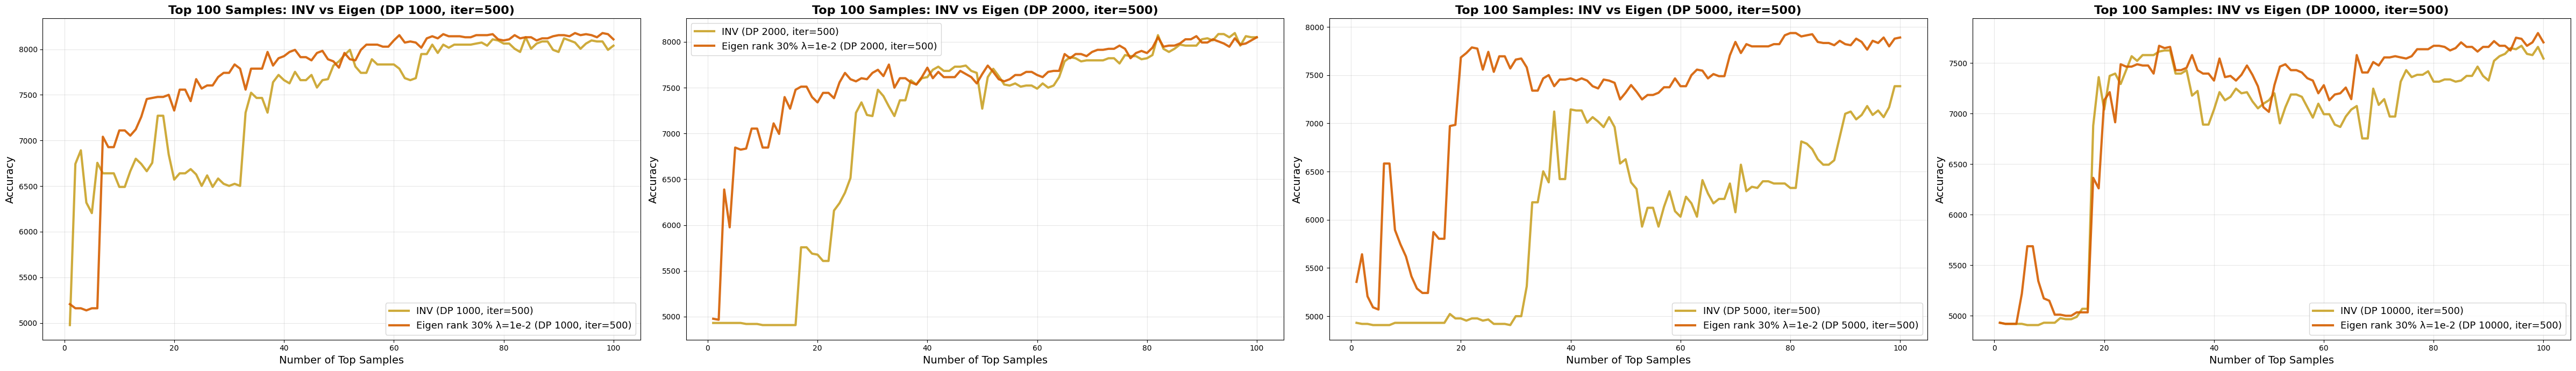

In [ ]:
# top 100 data
data = [i for i in range(1, 101)]
inv_1000              = 
eigen_1000_30_lam1e_2 = 

inv_2000              = 
eigen_2000_30_lam1e_2 = 

inv_5000              = 
eigen_5000_30_lam1e_2 = 

inv_10000              = 
eigen_10000_30_lam1e_2 = 

# Create (1,4) subplots
fig, axes = plt.subplots(1, 4, figsize=(48, 7))

# Color settings
inv_color = '#C9A227'
eigen_color = '#D55E00'  # Orange-red for eigen

# ===== Subplot (1,1): DP 1000 =====
ax_1000 = axes[0]

# Plot INV data (num_dp=1000)
ax_1000.plot(data, inv_1000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 1000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=1000, rank=30%, lambda=1e-2)
ax_1000.plot(data, eigen_1000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 1000, iter=500)', alpha=0.9)

ax_1000.set_xlabel('Number of Top Samples', fontsize=14)
ax_1000.set_ylabel('Accuracy', fontsize=14)
ax_1000.set_title('Top 100 Samples: INV vs Eigen (DP 1000, iter=500)', fontsize=16, fontweight='bold')
ax_1000.legend(fontsize=13, loc='best')
ax_1000.grid(True, alpha=0.3)

# ===== Subplot (1,2): DP 2000 =====
ax_2000 = axes[1]

# Plot INV data (num_dp=2000)
ax_2000.plot(data, inv_2000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 2000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=2000, rank=30%, lambda=1e-2)
ax_2000.plot(data, eigen_2000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 2000, iter=500)', alpha=0.9)

ax_2000.set_xlabel('Number of Top Samples', fontsize=14)
ax_2000.set_ylabel('Accuracy', fontsize=14)
ax_2000.set_title('Top 100 Samples: INV vs Eigen (DP 2000, iter=500)', fontsize=16, fontweight='bold')
ax_2000.legend(fontsize=13, loc='best')
ax_2000.grid(True, alpha=0.3)

# ===== Subplot (1,3): DP 5000 =====
ax_5000 = axes[2]

# Plot INV data (num_dp=5000)
ax_5000.plot(data, inv_5000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 5000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=5000, rank=30%, lambda=1e-2)
ax_5000.plot(data, eigen_5000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 5000, iter=500)', alpha=0.9)

ax_5000.set_xlabel('Number of Top Samples', fontsize=14)
ax_5000.set_ylabel('Accuracy', fontsize=14)
ax_5000.set_title('Top 100 Samples: INV vs Eigen (DP 5000, iter=500)', fontsize=16, fontweight='bold')
ax_5000.legend(fontsize=13, loc='best')
ax_5000.grid(True, alpha=0.3)

# ===== Subplot (1,4): DP 10000 =====
ax_10000 = axes[3]

# Plot INV data (num_dp=10000)
ax_10000.plot(data, inv_10000, 
        color=inv_color, linewidth=3, linestyle='-', 
        label='INV (DP 10000, iter=500)', alpha=0.9)

# Plot Eigen data (num_dp=10000, rank=30%, lambda=1e-2)
ax_10000.plot(data, eigen_10000_30_lam1e_2, 
        color=eigen_color, linewidth=3, linestyle='-', 
        label='Eigen rank 30% λ=1e-2 (DP 10000, iter=500)', alpha=0.9)

ax_10000.set_xlabel('Number of Top Samples', fontsize=14)
ax_10000.set_ylabel('Accuracy', fontsize=14)
ax_10000.set_title('Top 100 Samples: INV vs Eigen (DP 10000, iter=500)', fontsize=16, fontweight='bold')
ax_10000.legend(fontsize=13, loc='best')
ax_10000.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()